In [1]:
# =========================
# Step 0 — Load and Inspect Dataset (Google Drive)
# =========================

# Install gdown if not available
!pip install -q gdown

import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_colwidth", 200)

# -------- Google Drive file IDs --------
TRAIN_URL = "https://drive.google.com/uc?id=1MqWveEP-R8IVaGpGKT8rISi3wbPVkN9I"
TEST_URL  = "https://drive.google.com/uc?id=1RkCIzpKcxdelFEbFGDfj3yjBwde30tps"

# -------- Download files --------
gdown.download(TRAIN_URL, "train.csv", quiet=False)
gdown.download(TEST_URL,  "test.csv",  quiet=False)

# -------- Load data --------
train_df = pd.read_csv("train.csv")
test_df  = pd.read_csv("test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)

Downloading...
From: https://drive.google.com/uc?id=1MqWveEP-R8IVaGpGKT8rISi3wbPVkN9I
To: /content/train.csv
100%|██████████| 61.6M/61.6M [00:00<00:00, 129MB/s]
Downloading...
From: https://drive.google.com/uc?id=1RkCIzpKcxdelFEbFGDfj3yjBwde30tps
To: /content/test.csv
100%|██████████| 37.8M/37.8M [00:00<00:00, 59.1MB/s]


Train shape: (93333, 2)
Test shape : (59999, 2)


In [2]:
# -------- Preview --------
print("\nTrain head:")
display(train_df.head())

print("\nTest head:")
display(test_df.head())


Train head:


,QA Text,Class
0,<html> Question Title:\n <br> I have PCOS & would like to know more about a low GI diet??\n <br> <br> <br><br><br> Question Content:\n <br> I am only after positive & real answers.\n <br> <br>Best...,Health
1,<html> Question Title:\n <br> were to find some good skateboard trucks?\n <br> <br> <br><br><br> Question Content:\n <br> I have these over wieght core trucks and im looking for some independants ...,Sports
2,<html> Question Title:\n <br> where can i find info about how to survive a natural disaster like hurricane or an earthquake ?\n <br> <br> <br><br><br> Question Content:\n <br> \n <br> <br>Best Ans...,Science & Mathematics
3,"<html> Question Title:\n <br> Illegal immigration is a crime, agree/disagree?\n <br> <br> <br><br><br> Question Content:\n <br> \n <br> <br>Best Answer:\n <br> And what about Rapists!!! Fifty perc...",Politics & Government
4,"<html> Question Title:\n <br> ""Spare the rod and spoil the child"": What kind of parenting advice is that?\n <br> <br> <br><br><br> Question Content:\n <br> \n <br> <br>Best Answer:\n <br> All avai...",Society & Culture



Test head:


,QA Text,Class
0,<html>\nQuestion Title:<br>Why does Zebras have stripes?<br><br>Question Content:<br>What is the purpose or those stripes? Who do they serve the Zebras in the wild life?<br><br>Best Answer:<br>thi...,Science & Mathematics
1,<html>\nQuestion Title:<br>What did the itsy bitsy sipder climb up?<br><br>Question Content:<br><br><br>Best Answer:<br>waterspout\n</html>,Education & Reference
2,<html>\nQuestion Title:<br>What is the difference between a Bachelors and a Masters degree?<br><br>Question Content:<br><br><br>Best Answer:<br>One difference between a Bachelors and a Masters deg...,Education & Reference
3,<form>\nQuestion Title:<br>Why do women get PMS?<br><br>Question Content:<br><br><br>Best Answer:<br>Premenstrual syndrome (PMS) is a group of symptoms related to the menstrual cycle. PMS is linke...,Health
4,"<html>\nQuestion Title:<br>If your co-worker is guilty of unsanitary hygiene would it be right to tell him/her?<br><br>Question Content:<br><br><br>Best Answer:<br>Yes, it is your obligation. Espe...",Health


In [3]:
# -------- Dataset info --------
print("\nTrain info:")
train_df.info()

print("\nTest info:")
test_df.info()


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93333 entries, 0 to 93332
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   QA Text  93333 non-null  object
 1   Class    93333 non-null  object
dtypes: object(2)
memory usage: 1.4+ MB

Test info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59999 entries, 0 to 59998
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   QA Text  59999 non-null  object
 1   Class    59999 non-null  object
dtypes: object(2)
memory usage: 937.6+ KB


In [4]:
# -------- Column names --------
print("\nTrain columns:", list(train_df.columns))
print("Test columns :", list(test_df.columns))


Train columns: ['QA Text', 'Class']
Test columns : ['QA Text', 'Class']


In [5]:
# =========================
# Step 1 — Exploratory Data Analysis (EDA)
# =========================

import re
import nltk
from nltk.corpus import stopwords
from collections import Counter

nltk.download("stopwords")
STOPWORDS = set(stopwords.words("english"))

TEXT_COL  = "QA Text"
LABEL_COL = "Class"

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [6]:
# -------- Basic stats --------
train_df["char_len"] = train_df[TEXT_COL].astype(str).apply(len)
train_df["word_len"] = train_df[TEXT_COL].astype(str).apply(lambda x: len(x.split()))

print("Character length stats:")
display(train_df["char_len"].describe())

print("\nWord length stats:")
display(train_df["word_len"].describe())

Character length stats:


,char_len
count,93333.000000
mean,637.513752
std,584.690351
min,128.000000
25%,289.000000
50%,452.000000
75%,760.000000
max,7193.000000



Word length stats:


,word_len
count,93333.000000
mean,107.039632
std,99.871096
min,16.000000
25%,46.000000
50%,75.000000
75%,130.000000
max,1234.000000


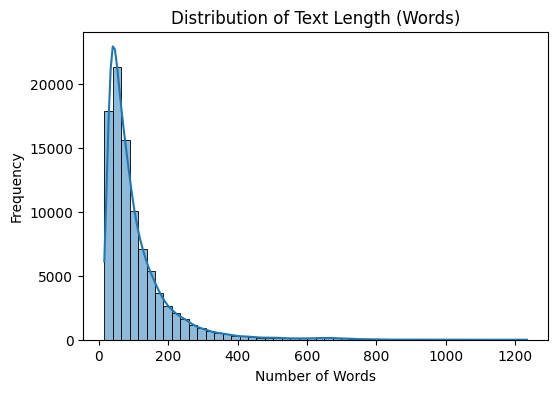

In [7]:
# -------- Text length distribution --------
plt.figure(figsize=(6,4))
sns.histplot(train_df["word_len"], bins=50, kde=True)
plt.title("Distribution of Text Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

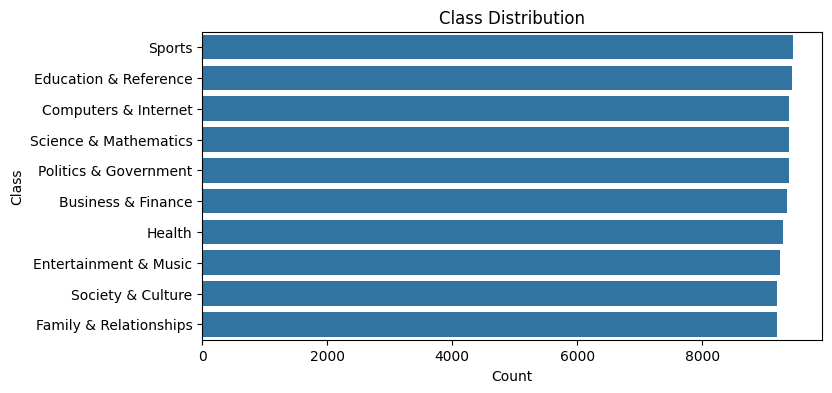

In [8]:
# -------- Class distribution --------
plt.figure(figsize=(8,4))
sns.countplot(y=train_df[LABEL_COL], order=train_df[LABEL_COL].value_counts().index)
plt.title("Class Distribution")
plt.xlabel("Count")
plt.ylabel("Class")
plt.show()

HTML tag count stats:


,html_tag_count
count,93333.000000
mean,12.009729
std,0.424383
min,12.000000
25%,12.000000
50%,12.000000
75%,12.000000
max,115.000000


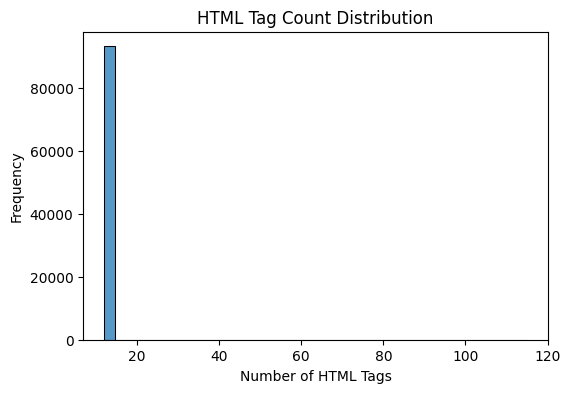

In [9]:
# -------- HTML tag analysis --------
def count_html_tags(text):
    return len(re.findall(r"<[^>]+>", text))

train_df["html_tag_count"] = train_df[TEXT_COL].apply(count_html_tags)

print("HTML tag count stats:")
display(train_df["html_tag_count"].describe())

plt.figure(figsize=(6,4))
sns.histplot(train_df["html_tag_count"], bins=40)
plt.title("HTML Tag Count Distribution")
plt.xlabel("Number of HTML Tags")
plt.ylabel("Frequency")
plt.show()

In [10]:
# -------- Tokenization & word frequency --------
def clean_basic(text):
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)   # remove HTML
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

train_df["clean_preview"] = train_df[TEXT_COL].astype(str).apply(clean_basic)

all_words = " ".join(train_df["clean_preview"]).split()
all_words_nostop = [w for w in all_words if w not in STOPWORDS]

print("Total tokens (with stopwords):", len(all_words))
print("Total tokens (without stopwords):", len(all_words_nostop))
print("Vocabulary size:", len(set(all_words)))

Total tokens (with stopwords): 9549467
Total tokens (without stopwords): 5185622
Vocabulary size: 160070


In [11]:
# -------- Top frequent words --------
top_words = Counter(all_words).most_common(20)
top_words_nostop = Counter(all_words_nostop).most_common(20)

print("\nTop 20 words (with stopwords):")
display(pd.DataFrame(top_words, columns=["Word", "Frequency"]))

print("\nTop 20 words (without stopwords):")
display(pd.DataFrame(top_words_nostop, columns=["Word", "Frequency"]))


Top 20 words (with stopwords):


,Word,Frequency
0,the,364228
1,to,238850
2,and,207260
3,a,206885
4,question,194893
5,i,183038
6,of,162105
7,you,156511
8,is,150259
9,n,134717



Top 20 words (without stopwords):


,Word,Frequency
0,question,194893
1,n,134717
2,best,103449
3,answer,100352
4,title,94133
5,content,93992
6,like,29918
7,get,29609
8,would,26619
9,one,26600


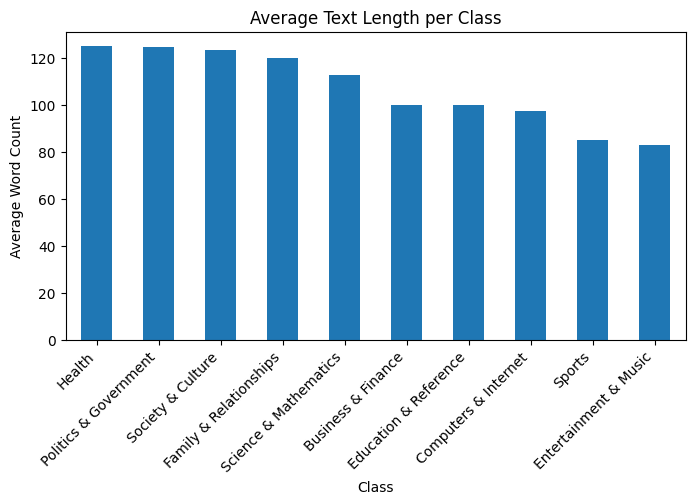

In [12]:
# -------- Class-wise average text length --------
class_len = train_df.groupby(LABEL_COL)["word_len"].mean().sort_values(ascending=False)

plt.figure(figsize=(8,4))
class_len.plot(kind="bar")
plt.title("Average Text Length per Class")
plt.ylabel("Average Word Count")
plt.xlabel("Class")
plt.xticks(rotation=45, ha="right")
plt.show()

In [13]:
# =========================
# Step 2 — Text Preprocessing (Based on EDA)
# =========================

import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

TEXT_COL  = "QA Text"
LABEL_COL = "Class"

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Dataset-specific boilerplate words (from EDA)
BOILERPLATE_WORDS = {
    "question", "answer", "title", "content", "best"
}

def clean_text(text, remove_stopwords=True):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove non-alphabetic characters
    text = re.sub(r"[^a-z\s]", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()

    # Remove boilerplate words
    tokens = [t for t in tokens if t not in BOILERPLATE_WORDS]

    # Stopword removal (TF-IDF only)
    if remove_stopwords:
        tokens = [t for t in tokens if t not in stop_words]

    # Lemmatization
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)

# -------- Apply preprocessing --------
# Version A: TF-IDF preprocessing
train_df["clean_tfidf"] = train_df[TEXT_COL].astype(str).apply(
    lambda x: clean_text(x, remove_stopwords=True)
)

test_df["clean_tfidf"] = test_df[TEXT_COL].astype(str).apply(
    lambda x: clean_text(x, remove_stopwords=True)
)

# Version B: Skip-gram / NN preprocessing
train_df["clean_nn"] = train_df[TEXT_COL].astype(str).apply(
    lambda x: clean_text(x, remove_stopwords=False)
)

test_df["clean_nn"] = test_df[TEXT_COL].astype(str).apply(
    lambda x: clean_text(x, remove_stopwords=False)
)

# -------- Preview cleaned text --------
print("Original text sample:\n")
print(train_df[TEXT_COL].iloc[0][:500], "\n")

print("TF-IDF cleaned text sample:\n")
print(train_df["clean_tfidf"].iloc[0][:500], "\n")

print("NN cleaned text sample:\n")
print(train_df["clean_nn"].iloc[0][:500], "\n")

print("Step 2 preprocessing completed successfully.")


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Original text sample:

<html> Question Title:
 <br> I have PCOS & would like to know more about a low GI diet??
 <br> <br> <br><br><br> Question Content:
 <br> I am only after positive & real answers.
 <br> <br>Best Answer:
 <br> I also have PCOS and I highly recommend the SugarBusters diet.  It helped immensely.  I've lost about 25 lbs on it. </html> 

TF-IDF cleaned text sample:

pcos would like know low gi diet positive real answer also pcos highly recommend sugarbusters diet helped immensely lost lb 

NN cleaned text sample:

i have pcos would like to know more about a low gi diet i am only after positive real answer i also have pcos and i highly recommend the sugarbusters diet it helped immensely i ve lost about lb on it 

Step 2 preprocessing completed successfully.


In [ ]:
# =========================
# Step 3 — TF-IDF Representation & Data Preparation
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer

# -------- Columns --------
TEXT_COL  = "clean_tfidf"   # from Step 2
LABEL_COL = "Class"

# -------- Encode labels --------
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train_df[LABEL_COL])
y_test = label_encoder.transform(test_df[LABEL_COL])

print("Number of classes:", len(label_encoder.classes_))
print("Classes:", label_encoder.classes_)

# -------- Train / Validation split --------
X_train_text, X_val_text, y_train, y_val = train_test_split(
    train_df[TEXT_COL],
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train_text.shape[0])
print("Validation size:", X_val_text.shape[0])

# -------- TF-IDF Vectorizer --------
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    min_df=5,
    max_df=0.9,
    sublinear_tf=True
)

# -------- Fit & transform --------
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_text)
X_val_tfidf   = tfidf_vectorizer.transform(X_val_text)
X_test_tfidf  = tfidf_vectorizer.transform(test_df[TEXT_COL])

print("TF-IDF Train shape:", X_train_tfidf.shape)
print("TF-IDF Validation shape:", X_val_tfidf.shape)
print("TF-IDF Test shape:", X_test_tfidf.shape)

# -------- Convert to dense for DNN --------
X_train_tfidf_dense = X_train_tfidf.toarray()
X_val_tfidf_dense   = X_val_tfidf.toarray()
X_test_tfidf_dense  = X_test_tfidf.toarray()

print("Dense TF-IDF shape (Train):", X_train_tfidf_dense.shape)

print("Step 3 TF-IDF preparation completed successfully.")


Number of classes: 10
Classes: ['Business & Finance' 'Computers & Internet' 'Education & Reference'
 'Entertainment & Music' 'Family & Relationships' 'Health'
 'Politics & Government' 'Science & Mathematics' 'Society & Culture'
 'Sports']
Train size: 74666
Validation size: 18667
TF-IDF Train shape: (74666, 50000)
TF-IDF Validation shape: (18667, 50000)
TF-IDF Test shape: (59999, 50000)


In [ ]:
# =========================
# Skip-gram (Word2Vec SG) Representation for NN Models
# =========================

!pip install -q gensim tensorflow

import numpy as np
from gensim.models import Word2Vec
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Use NN-cleaned text from Step 2
TEXT_COL_NN = "clean_nn"
LABEL_COL = "Class"

# Hyperparameters (tune later)
EMBED_DIM = 200
WINDOW = 5
MIN_COUNT = 5
SG = 1              # 1 = Skip-gram, 0 = CBOW
MAX_VOCAB = 50000
MAX_LEN = 150       # from EDA (you can test 150 vs 200)

# -------- Prepare tokenized sentences for Word2Vec --------
sentences = train_df[TEXT_COL_NN].astype(str).apply(lambda x: x.split()).tolist()

print("Example tokenized sentence:", sentences[0][:30])

# -------- Train Word2Vec Skip-gram on training set --------
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=EMBED_DIM,
    window=WINDOW,
    min_count=MIN_COUNT,
    workers=4,
    sg=SG
)

print("Word2Vec vocabulary size:", len(w2v_model.wv.index_to_key))

# -------- Keras Tokenizer (controls vocab size for NN) --------
tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df[TEXT_COL_NN].astype(str))

# Apply the same train/validation split as used for TF-IDF to the NN-cleaned text
X_full_nn_text = train_df[TEXT_COL_NN].astype(str)

# The 'y' from TF-IDF step (cell gTfIlqlH-_Nh) is the full label array
# We use the same stratification and random_state to ensure consistent splits
_, _, _, _ = train_test_split(
    X_full_nn_text, # We only need the text splits, y_train and y_val are already defined
    y, # Use the full 'y' for stratification consistency
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train_nn_text_indices = y_train.index if isinstance(y_train, pd.Series) else None # Ensure we get original indices
X_val_nn_text_indices = y_val.index if isinstance(y_val, pd.Series) else None

# Recreate the text splits based on the indices from the original split
X_train_nn_text = train_df.loc[X_train_text.index, TEXT_COL_NN].astype(str)
X_val_nn_text = train_df.loc[X_val_text.index, TEXT_COL_NN].astype(str)

# Convert to sequences for the split data
X_train_seq = tokenizer.texts_to_sequences(X_train_nn_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_nn_text)
X_test_seq  = tokenizer.texts_to_sequences(test_df[TEXT_COL_NN].astype(str))

# Pad sequences
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding="post", truncating="post")

print("Padded train shape:", X_train_pad.shape)
print("Padded validation shape:", X_val_pad.shape)
print("Padded test shape :", X_test_pad.shape)

# -------- Build embedding matrix --------
word_index = tokenizer.word_index
num_words = min(MAX_VOCAB, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM))

hits = 0
misses = 0

for word, i in word_index.items():
    if i >= num_words:
        continue
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]
        hits += 1
    else:
        misses += 1

print(f"Embedding coverage: {hits}/{hits+misses} words found in Word2Vec")

print("Skip-gram preparation completed successfully.")

In [ ]:
# =========================
# TF-IDF + Logistic Regression (Manual Hyperparameter Tuning)
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

# ----- Manual tuning grid (edit/extend if you want) -----
C_list = [0.1, 0.3, 1.0, 3.0, 10.0]
ngram_note = "(TF-IDF already fixed from Step 3: ngram_range=(1,2), max_features=50000, min_df=5)"

results = []

best_model = None
best_row = None
best_f1 = -1

for C in C_list:
    clf = LogisticRegression(
        C=C,
        max_iter=3000,
        n_jobs=-1,
        solver="lbfgs",
        multi_class="auto"
    )
    clf.fit(X_train_tfidf, y_train)

    val_pred = clf.predict(X_val_tfidf)
    acc = accuracy_score(y_val, val_pred)
    f1m = f1_score(y_val, val_pred, average="macro")

    results.append({"C": C, "val_accuracy": acc, "val_macro_f1": f1m})

    if f1m > best_f1:
        best_f1 = f1m
        best_model = clf
        best_row = results[-1]

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)

print("=== Logistic Regression Tuning Results ===")
print(ngram_note)
display(results_df)

print("\nBest hyperparameters (by Val Macro F1):", best_row)

# ----- Validation evaluation (best model) -----
val_pred = best_model.predict(X_val_tfidf)

val_acc = accuracy_score(y_val, val_pred)
val_f1m = f1_score(y_val, val_pred, average="macro")

print("\n=== Best Model on Validation Set ===")
print("Validation Accuracy :", val_acc)
print("Validation Macro F1 :", val_f1m)

print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

# Confusion matrix (validation)
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, cmap="Blues", cbar=True)
plt.title("Confusion Matrix (Validation) — TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ----- Final test evaluation (STRICTLY final evaluation) -----
# NOTE: This evaluates the chosen model on the test set. Do NOT use this to tune further.
test_pred = best_model.predict(X_test_tfidf)

test_acc = accuracy_score(y_test, test_pred)
test_f1m = f1_score(y_test, test_pred, average="macro")

print("\n=== Final Evaluation on Test Set (No Tuning Here) ===")
print("Test Accuracy :", test_acc)
print("Test Macro F1 :", test_f1m)

print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_test, cmap="Blues", cbar=True)
plt.title("Confusion Matrix (Test) — TF-IDF + Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
# =========================
# TF-IDF + DNN (Sparse-safe) with Manual Hyperparameter Tuning
# =========================

!pip install -q tensorflow scikit-learn

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

num_classes = len(label_encoder.classes_)
input_dim = X_train_tfidf.shape[1]

print("Input dim (TF-IDF features):", input_dim)
print("Num classes:", num_classes)

# ---- Convert scipy sparse -> tf.sparse.SparseTensor ----
def scipy_to_tf_sparse(X):
    X = X.tocoo()
    indices = np.vstack((X.row, X.col)).T.astype(np.int64)
    values = X.data.astype(np.float32)
    shape = np.array(X.shape, dtype=np.int64)
    return tf.sparse.SparseTensor(indices=indices, values=values, dense_shape=shape)

Xtr_sp = scipy_to_tf_sparse(X_train_tfidf)
Xva_sp = scipy_to_tf_sparse(X_val_tfidf)
Xte_sp = scipy_to_tf_sparse(X_test_tfidf)

# Make sure indices are sorted (TensorFlow prefers it)
Xtr_sp = tf.sparse.reorder(Xtr_sp)
Xva_sp = tf.sparse.reorder(Xva_sp)
Xte_sp = tf.sparse.reorder(Xte_sp)

# ---- Build sparse-aware MLP ----
def build_sparse_mlp(input_dim, num_classes, hidden_units=(512, 256), dropout=0.4, lr=1e-3, l2=0.0):
    reg = tf.keras.regularizers.l2(l2) if l2 and l2 > 0 else None

    inputs = tf.keras.Input(shape=(input_dim,), sparse=True)
    x = inputs

    for u in hidden_units:
        x = tf.keras.layers.Dense(u, activation="relu", kernel_regularizer=reg)(x)
        x = tf.keras.layers.Dropout(dropout)(x)

    outputs = tf.keras.layers.Dense(num_classes, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

# ---- Manual tuning configs (small but valid) ----
configs = [
    {"hidden_units": (512,),      "dropout": 0.3, "lr": 1e-3,  "batch": 256, "l2": 0.0},
    {"hidden_units": (512, 256),  "dropout": 0.4, "lr": 1e-3,  "batch": 256, "l2": 0.0},
    {"hidden_units": (1024, 256), "dropout": 0.5, "lr": 7e-4,  "batch": 256, "l2": 1e-6},
    {"hidden_units": (512, 256),  "dropout": 0.5, "lr": 3e-4,  "batch": 512, "l2": 1e-6},
]

EPOCHS = 20
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

results = []
best = {"val_f1": -1, "model": None, "cfg": None, "history": None}

# ---- Train & validate ----
for i, cfg in enumerate(configs, start=1):
    print(f"\n=== Run {i}/{len(configs)} | cfg={cfg} ===")
    model = build_sparse_mlp(
        input_dim=input_dim,
        num_classes=num_classes,
        hidden_units=cfg["hidden_units"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        l2=cfg["l2"]
    )

    history = model.fit(
        Xtr_sp, y_train,
        validation_data=(Xva_sp, y_val),
        epochs=EPOCHS,
        batch_size=cfg["batch"],
        callbacks=[early_stop],
        verbose=1
    )

    val_probs = model.predict(Xva_sp, batch_size=1024, verbose=0)
    val_pred = np.argmax(val_probs, axis=1)

    val_acc = accuracy_score(y_val, val_pred)
    val_f1  = f1_score(y_val, val_pred, average="macro")

    results.append({**cfg, "val_accuracy": val_acc, "val_macro_f1": val_f1})
    print(f"Validation Accuracy: {val_acc:.4f} | Validation Macro F1: {val_f1:.4f}")

    if val_f1 > best["val_f1"]:
        best.update({"val_f1": val_f1, "model": model, "cfg": cfg, "history": history})

results_df = pd.DataFrame(results).sort_values("val_macro_f1", ascending=False)
print("\n=== DNN Tuning Results (sorted by Val Macro F1) ===")
display(results_df)

print("\nBest config:", best["cfg"])
print("Best Val Macro F1:", best["val_f1"])

# ---- Training curve ----
hist = best["history"].history
plt.figure(figsize=(6,4))
plt.plot(hist["loss"], label="train_loss")
plt.plot(hist["val_loss"], label="val_loss")
plt.title("Best Sparse DNN Training Curve (Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

best_model = best["model"]

# ---- Validation metrics ----
val_probs = best_model.predict(Xva_sp, batch_size=1024, verbose=0)
val_pred = np.argmax(val_probs, axis=1)

print("\n=== Best DNN on Validation ===")
print("Validation Accuracy:", accuracy_score(y_val, val_pred))
print("Validation Macro F1:", f1_score(y_val, val_pred, average="macro"))
print("\nClassification Report (Validation):")
print(classification_report(y_val, val_pred, target_names=label_encoder.classes_))

# ---- Confusion matrix (avoid huge plot if many classes) ----
cm_val = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm_val, interpolation="nearest")
plt.title("Confusion Matrix (Validation) — TF-IDF + Sparse DNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

# ---- Final test evaluation ----
test_probs = best_model.predict(Xte_sp, batch_size=1024, verbose=0)
test_pred = np.argmax(test_probs, axis=1)

print("\n=== Final Evaluation on Test (TF-IDF + Sparse DNN) ===")
print("Test Accuracy:", accuracy_score(y_test, test_pred))
print("Test Macro F1:", f1_score(y_test, test_pred, average="macro"))
print("\nClassification Report (Test):")
print(classification_report(y_test, test_pred, target_names=label_encoder.classes_))

cm_test = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(8,6))
plt.imshow(cm_test, interpolation="nearest")
plt.title("Confusion Matrix (Test) — TF-IDF + Sparse DNN")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.show()

print("\nTF-IDF + DNN (sparse-safe) completed successfully.")


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report

tf.random.set_seed(42)
np.random.seed(42)

NUM_CLASSES = len(label_encoder.classes_)
VOCAB_SIZE, EMBED_DIM = embedding_matrix.shape
MAX_LEN = X_train_pad.shape[1] # Changed from X_tr_pad as X_tr_pad is not defined.

print("NUM_CLASSES:", NUM_CLASSES)
print("VOCAB_SIZE:", VOCAB_SIZE, "EMBED_DIM:", EMBED_DIM, "MAX_LEN:", MAX_LEN)

def eval_and_print(model, X, y, split_name="VAL"):
    probs = model.predict(X, batch_size=1024, verbose=0)
    pred = np.argmax(probs, axis=1)
    acc = accuracy_score(y, pred)
    f1m = f1_score(y, pred, average="macro")
    print(f"\n=== {split_name} RESULTS ===")
    print("Accuracy:", acc)
    print("Macro F1 :", f1m)
    print("\nClassification Report:")
    print(classification_report(y, pred, target_names=label_encoder.classes_))

    cm = confusion_matrix(y, pred)
    plt.figure(figsize=(7,6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(f"Confusion Matrix ({split_name})")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.colorbar()
    plt.show()
    return acc, f1m

def train_with_manual_tuning(build_fn, configs, model_name):
    """
    build_fn(cfg) -> compiled tf.keras.Model
    configs: list of dict hyperparams
    Select best by validation macro-F1
    """
    best = {"val_f1": -1, "cfg": None, "model": None, "history": None}
    rows = []

    for i, cfg in enumerate(configs, start=1):
        print(f"\n[{model_name}] Run {i}/{len(configs)} cfg={cfg}")

        model = build_fn(cfg)
        es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

        history = model.fit(
            X_train_pad, y_train, # Changed from X_tr_pad, y_tr as they are not defined
            validation_data=(X_val_pad, y_val),
            epochs=cfg.get("epochs", 10),
            batch_size=cfg.get("batch", 128),
            callbacks=[es],
            verbose=1
        )

        # validation metrics
        val_probs = model.predict(X_val_pad, batch_size=1024, verbose=0)
        val_pred = np.argmax(val_probs, axis=1)
        val_acc = accuracy_score(y_val, val_pred)
        val_f1 = f1_score(y_val, val_pred, average="macro")

        rows.append({**cfg, "val_accuracy": val_acc, "val_macro_f1": val_f1})
        print(f"[{model_name}] Val Acc={val_acc:.4f} Val MacroF1={val_f1:.4f}")

        if val_f1 > best["val_f1"]:
            best.update({"val_f1": val_f1, "cfg": cfg, "model": model, "history": history})

    import pandas as pd
    res_df = pd.DataFrame(rows).sort_values("val_macro_f1", ascending=False)
    print(f"\n=== {model_name} Tuning Table (sorted by Val Macro F1) ===")
    display(res_df)
    print(f"BEST {model_name} cfg:", best["cfg"], "BEST Val MacroF1:", best["val_f1"])

    # training curve
    hist = best["history"].history
    plt.figure(figsize=(6,4))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{model_name} Training Curve (Loss)")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    return best


In [ ]:
# =========================
# Skip-gram NN Experiments — Model Builders (7 required)
# =========================

def base_embedding(trainable=False):
    # Embedding layer initialized with Skip-gram vectors
    return tf.keras.layers.Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=trainable
    )

def build_dnn_emb(cfg):
    # DNN over embeddings: Embedding -> GlobalAveragePooling -> Dense...
    inputs = tf.keras.Input(shape=(MAX_LEN,))
    x = base_embedding(trainable=cfg.get("trainable_emb", False))(inputs)
    x = tf.keras.layers.GlobalAveragePooling1D()(x)
    for u in cfg.get("dense_units", [256]):
        x = tf.keras.layers.Dense(u, activation="relu")(x)
        x = tf.keras.layers.Dropout(cfg.get("dropout", 0.4))(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.get("lr", 1e-3)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_simplernn(cfg, bidir=False):
    inputs = tf.keras.Input(shape=(MAX_LEN,))
    x = base_embedding(trainable=cfg.get("trainable_emb", False))(inputs)
    rnn = tf.keras.layers.SimpleRNN(cfg.get("units", 128), dropout=cfg.get("dropout", 0.3))
    x = tf.keras.layers.Bidirectional(rnn)(x) if bidir else rnn(x)
    x = tf.keras.layers.Dense(cfg.get("dense", 128), activation="relu")(x)
    x = tf.keras.layers.Dropout(cfg.get("dropout2", 0.4))(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.get("lr", 1e-3)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_gru(cfg, bidir=False):
    inputs = tf.keras.Input(shape=(MAX_LEN,))
    x = base_embedding(trainable=cfg.get("trainable_emb", False))(inputs)
    rnn = tf.keras.layers.GRU(cfg.get("units", 128), dropout=cfg.get("dropout", 0.3))
    x = tf.keras.layers.Bidirectional(rnn)(x) if bidir else rnn(x)
    x = tf.keras.layers.Dense(cfg.get("dense", 128), activation="relu")(x)
    x = tf.keras.layers.Dropout(cfg.get("dropout2", 0.4))(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.get("lr", 1e-3)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

def build_lstm(cfg, bidir=False):
    inputs = tf.keras.Input(shape=(MAX_LEN,))
    x = base_embedding(trainable=cfg.get("trainable_emb", False))(inputs)
    rnn = tf.keras.layers.LSTM(cfg.get("units", 128), dropout=cfg.get("dropout", 0.3))
    x = tf.keras.layers.Bidirectional(rnn)(x) if bidir else rnn(x)
    x = tf.keras.layers.Dense(cfg.get("dense", 128), activation="relu")(x)
    x = tf.keras.layers.Dropout(cfg.get("dropout2", 0.4))(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg.get("lr", 1e-3)),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


In [ ]:
# =========================
# Skip-gram + 7 NN Models — Training Runs + Evaluation
# =========================

ALL_RESULTS = []

def run_experiment(model_name, build_fn, configs):
    best = train_with_manual_tuning(build_fn, configs, model_name)

    print(f"\n######## Best {model_name} on VALIDATION ########")
    val_acc, val_f1 = eval_and_print(best["model"], X_val_pad, y_val, split_name=f"{model_name} VAL")

    print(f"\n######## Best {model_name} on TEST (final for this model) ########")
    test_acc, test_f1 = eval_and_print(best["model"], X_test_pad, y_test, split_name=f"{model_name} TEST")

    ALL_RESULTS.append({
        "model": model_name,
        "best_cfg": best["cfg"],
        "val_accuracy": val_acc,
        "val_macro_f1": val_f1,
        "test_accuracy": test_acc,
        "test_macro_f1": test_f1
    })

# ---- 1) DNN (Embedding-based) ----
dnn_configs = [
    {"dense_units": [256],      "dropout": 0.4, "lr": 1e-3, "batch": 256, "epochs": 8, "trainable_emb": False},
    {"dense_units": [512, 256], "dropout": 0.5, "lr": 7e-4, "batch": 256, "epochs": 10, "trainable_emb": False},
]
run_experiment("SkipGram-DNN", build_dnn_emb, dnn_configs)

# ---- 2) SimpleRNN ----
srnn_configs = [
    {"units": 128, "dropout": 0.3, "dense": 128, "dropout2": 0.4, "lr": 1e-3, "batch": 128, "epochs": 6, "trainable_emb": False},
    {"units": 256, "dropout": 0.4, "dense": 128, "dropout2": 0.5, "lr": 7e-4, "batch": 128, "epochs": 8, "trainable_emb": False},
]
run_experiment("SkipGram-SimpleRNN", lambda cfg: build_simplernn(cfg, bidir=False), srnn_configs)

# ---- 3) GRU ----
gru_configs = [
    {"units": 128, "dropout": 0.3, "dense": 128, "dropout2": 0.4, "lr": 1e-3, "batch": 128, "epochs": 6, "trainable_emb": False},
    {"units": 256, "dropout": 0.4, "dense": 128, "dropout2": 0.5, "lr": 7e-4, "batch": 128, "epochs": 8, "trainable_emb": False},
]
run_experiment("SkipGram-GRU", lambda cfg: build_gru(cfg, bidir=False), gru_configs)

# ---- 4) LSTM ----
lstm_configs = [
    {"units": 128, "dropout": 0.3, "dense": 128, "dropout2": 0.4, "lr": 1e-3, "batch": 128, "epochs": 6, "trainable_emb": False},
    {"units": 256, "dropout": 0.4, "dense": 128, "dropout2": 0.5, "lr": 7e-4, "batch": 128, "epochs": 8, "trainable_emb": False},
]
run_experiment("SkipGram-LSTM", lambda cfg: build_lstm(cfg, bidir=False), lstm_configs)

# ---- 5) Bidirectional SimpleRNN ----
bisrnn_configs = [
    {"units": 128, "dropout": 0.3, "dense": 128, "dropout2": 0.4, "lr": 1e-3, "batch": 128, "epochs": 6, "trainable_emb": False},
    {"units": 256, "dropout": 0.4, "dense": 128, "dropout2": 0.5, "lr": 7e-4, "batch": 128, "epochs": 8, "trainable_emb": False},
]
run_experiment("SkipGram-BiSimpleRNN", lambda cfg: build_simplernn(cfg, bidir=True), bisrnn_configs)

# ---- 6) Bidirectional GRU ----
bigru_configs = [
    {"units": 128, "dropout": 0.3, "dense": 128, "dropout2": 0.4, "lr": 1e-3, "batch": 128, "epochs": 6, "trainable_emb": False},
    {"units": 256, "dropout": 0.4, "dense": 128, "dropout2": 0.5, "lr": 7e-4, "batch": 128, "epochs": 8, "trainable_emb": False},
]
run_experiment("SkipGram-BiGRU", lambda cfg: build_gru(cfg, bidir=True), bigru_configs)

# ---- 7) Bidirectional LSTM ----
bilstm_configs = [
    {"units": 128, "dropout": 0.3, "dense": 128, "dropout2": 0.4, "lr": 1e-3, "batch": 128, "epochs": 6, "trainable_emb": False},
    {"units": 256, "dropout": 0.4, "dense": 128, "dropout2": 0.5, "lr": 7e-4, "batch": 128, "epochs": 8, "trainable_emb": False},
]
run_experiment("SkipGram-BiLSTM", lambda cfg: build_lstm(cfg, bidir=True), bilstm_configs)

# ---- Summary table ----
import pandas as pd
summary_df = pd.DataFrame(ALL_RESULTS).sort_values("test_macro_f1", ascending=False)
print("\n==================== SUMMARY (sorted by Test Macro F1) ====================")
display(summary_df)

print("\nBest model:", summary_df.iloc[0]["model"], "Test Macro F1:", summary_df.iloc[0]["test_macro_f1"])
print("Worst model:", summary_df.iloc[-1]["model"], "Test Macro F1:", summary_df.iloc[-1]["test_macro_f1"])
